In [ ]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


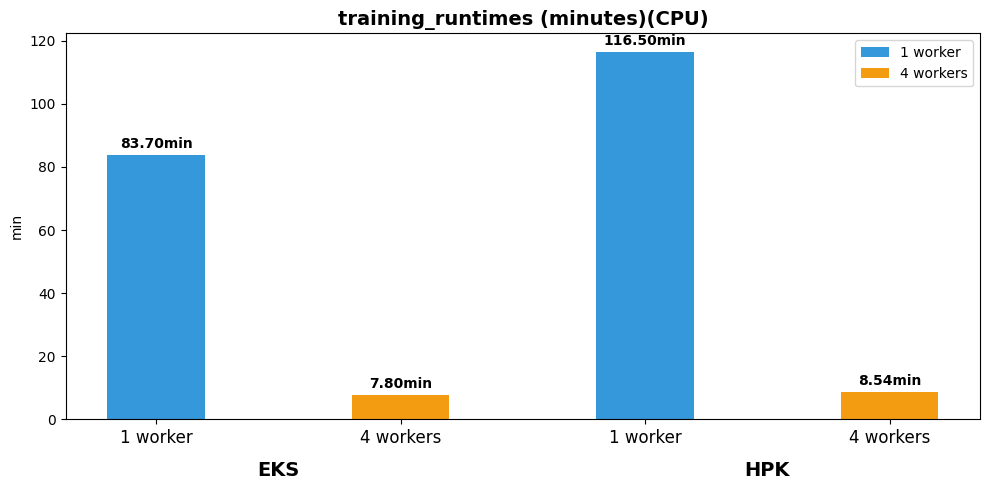

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Example durations (replace with your actual data)
durations = {
    'EKS': [83.7, 7.8],
    'HPK': [116.5, 8.54]
}
worker_labels = ['1 worker', '4 workers']
way_labels = list(durations.keys())

# Custom x positions for spacing between groups
group_gap = 0.6  # reduced gap between EKS and HPK
bar_width = 0.4

x_way_a = np.array([0, 1])  # EKS
x_way_b = np.array([0, 1]) + (1.4 + group_gap)  # HPK now closer to EKS

fig, ax = plt.subplots(figsize=(10, 5))  # Reduced height

# Colors: 1 worker = blue, 4 workers = orange
colors = ['#3498db', '#f39c12']

# Plot bars
bars_a = ax.bar(x_way_a, durations['EKS'], width=bar_width, color=colors)
bars_b = ax.bar(x_way_b, durations['HPK'], width=bar_width, color=colors)

# Set x-ticks and labels
all_x = np.concatenate([x_way_a, x_way_b])
all_worker_labels = worker_labels * 2
ax.set_xticks(all_x)
ax.set_xticklabels(all_worker_labels, fontsize=12)

# Group labels (EKS, HPK)
group_centers = [np.mean(x_way_a), np.mean(x_way_b)]
for center, label in zip(group_centers, way_labels):
    ax.annotate(label, xy=(center, 0), xytext=(0, -30), textcoords='offset points',
                ha='center', va='top', fontsize=14, fontweight='bold', xycoords=('data', 'axes fraction'))

ax.set_ylabel('min')
ax.set_title('training_runtimes (minutes)(CPU)(Old script)', fontsize=14, fontweight='bold')

# Legend
legend_elements = [
    Patch(facecolor=colors[0], label='1 worker'),
    Patch(facecolor=colors[1], label='4 workers')
]
ax.legend(handles=legend_elements)

# Value labels
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}min',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(bars_a)
autolabel(bars_b)

# Adjust layout
plt.subplots_adjust(bottom=0.18)
plt.tight_layout()
plt.show()


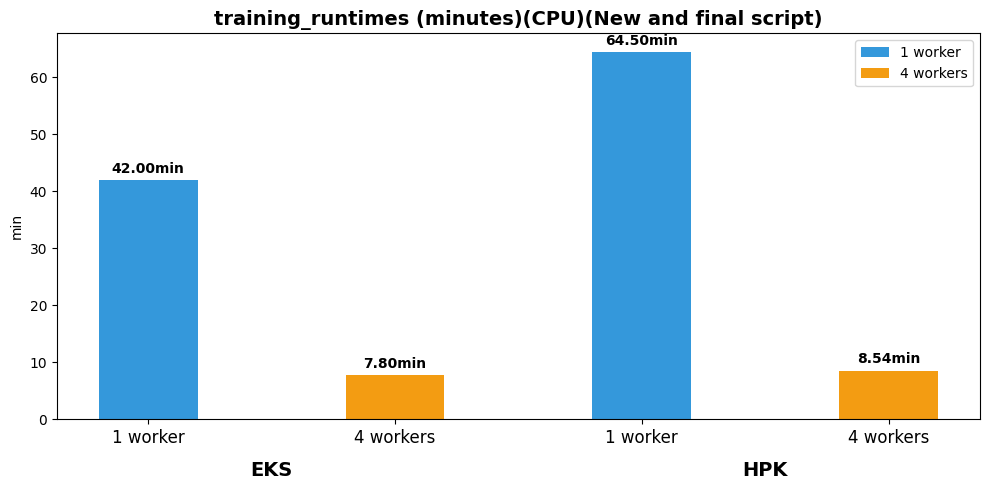

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Example durations (replace with your actual data)
durations = {
    'EKS': [42, 7.8],
    'HPK': [64.5, 8.54]
}
worker_labels = ['1 worker', '4 workers']
way_labels = list(durations.keys())

# Custom x positions for spacing between groups
group_gap = 0.6  # reduced gap between EKS and HPK
bar_width = 0.4

x_way_a = np.array([0, 1])  # EKS
x_way_b = np.array([0, 1]) + (1.4 + group_gap)  # HPK now closer to EKS

fig, ax = plt.subplots(figsize=(10, 5))  # Reduced height

# Colors: 1 worker = blue, 4 workers = orange
colors = ['#3498db', '#f39c12']

# Plot bars
bars_a = ax.bar(x_way_a, durations['EKS'], width=bar_width, color=colors)
bars_b = ax.bar(x_way_b, durations['HPK'], width=bar_width, color=colors)

# Set x-ticks and labels
all_x = np.concatenate([x_way_a, x_way_b])
all_worker_labels = worker_labels * 2
ax.set_xticks(all_x)
ax.set_xticklabels(all_worker_labels, fontsize=12)

# Group labels (EKS, HPK)
group_centers = [np.mean(x_way_a), np.mean(x_way_b)]
for center, label in zip(group_centers, way_labels):
    ax.annotate(label, xy=(center, 0), xytext=(0, -30), textcoords='offset points',
                ha='center', va='top', fontsize=14, fontweight='bold', xycoords=('data', 'axes fraction'))

ax.set_ylabel('min')
ax.set_title('training_runtimes (minutes)(CPU)(New and final script)', fontsize=14, fontweight='bold')

# Legend
legend_elements = [
    Patch(facecolor=colors[0], label='1 worker'),
    Patch(facecolor=colors[1], label='4 workers')
]
ax.legend(handles=legend_elements)

# Value labels
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}min',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(bars_a)
autolabel(bars_b)

# Adjust layout
plt.subplots_adjust(bottom=0.18)
plt.tight_layout()
plt.show()


### Results from HPK with 1 worker, no GPU:

- {'eval_loss': 1.0756864547729492, 'eval_accuracy': 0.51, 'eval_runtime': 55.1886, 'eval_samples_per_second': 7.248, 'eval_steps_per_second': 7.248, 'epoch': 1.0}
- {'eval_loss': 1.1918613910675049, 'eval_accuracy': 0.5125, 'eval_runtime': 54.9001, 'eval_samples_per_second': 7.286, 'eval_steps_per_second': 7.286, 'epoch': 2.0}
- {'eval_loss': 1.4866937398910522, 'eval_accuracy': 0.5225, 'eval_runtime': 54.808, 'eval_samples_per_second': 7.298, 'eval_steps_per_second': 7.298, 'epoch': 3.0}

{'train_runtime': 6991.731, 'train_samples_per_second': 1.545, 'train_steps_per_second': 0.193, 'train_loss': 0.8642607173213253, 'epoch': 3.0} ~= 116.5 minutes


### Results from EKS with 1 worker, no GPU:

- {'eval_loss': 1.1081103086471558, 'eval_accuracy': 0.515, 'eval_runtime': 31.9119, 'eval_samples_per_second': 12.534, 'eval_steps_per_second': 12.534, 'epoch': 1.0}
- {'eval_loss': 1.0622544288635254, 'eval_accuracy': 0.56, 'eval_runtime': 37.5659, 'eval_samples_per_second': 10.648, 'eval_steps_per_second': 10.648, 'epoch': 2.0}
- {'eval_loss': 1.2298154830932617, 'eval_accuracy': 0.58, 'eval_runtime': 33.1493, 'eval_samples_per_second': 12.067, 'eval_steps_per_second': 12.067, 'epoch': 3.0}

{'train_runtime': 5023.2359, 'train_samples_per_second': 2.15, 'train_steps_per_second': 0.269, 'train_loss': 0.9660257749204283, 'epoch': 3.0} ~= 83.7 minutes

### Results from HPK with 4 workers, no GPU:

- {'eval_loss': 1.375880479812622, 'eval_accuracy': 0.36, 'eval_runtime': 3.716, 'eval_samples_per_second': 26.91, 'eval_steps_per_second': 6.728, 'epoch': 1.0}
- {'eval_loss': 1.1750472784042358, 'eval_accuracy': 0.47, 'eval_runtime': 3.8654, 'eval_samples_per_second': 25.87, 'eval_steps_per_second': 6.468, 'epoch': 1.99}
- {'eval_loss': 1.0873456001281738, 'eval_accuracy': 0.51, 'eval_runtime': 3.7964, 'eval_samples_per_second': 26.341, 'eval_steps_per_second': 6.585, 'epoch': 2.99}

{'train_runtime': 512.8043, 'train_samples_per_second': 5.265, 'train_steps_per_second': 0.164, 'train_loss': 1.3346944536481584, 'epoch': 2.99} ~= 8.54 minutes


### Results from HPK with 4 workers, no GPU: (with --cpus-per-task instead of --ntasks-per-node)

- {'eval_loss': 1.3715404272079468, 'eval_accuracy': 0.49, 'eval_runtime': 3.7907, 'eval_samples_per_second': 26.38, 'eval_steps_per_second': 6.595, 'epoch': 1.0}
- {'eval_loss': 1.1752314567565918, 'eval_accuracy': 0.54, 'eval_runtime': 3.8343, 'eval_samples_per_second': 26.08, 'eval_steps_per_second': 6.52, 'epoch': 1.99}
- {'eval_loss': 1.0772199630737305, 'eval_accuracy': 0.57, 'eval_runtime': 3.7923, 'eval_samples_per_second': 26.369, 'eval_steps_per_second': 6.592, 'epoch': 2.99}

{'train_runtime': 511.2224, 'train_samples_per_second': 5.281, 'train_steps_per_second': 0.164, 'train_loss': 1.325916017804827, 'epoch': 2.99} ~= 8.52 minutes

### Results from EKS with 4 workers, no GPU:

- {'eval_loss': 1.5554237365722656, 'eval_accuracy': 0.26, 'eval_runtime': 3.2417, 'eval_samples_per_second': 30.848, 'eval_steps_per_second': 7.712, 'epoch': 1.0}
- {'eval_loss': 1.278393030166626, 'eval_accuracy': 0.46, 'eval_runtime': 4.3298, 'eval_samples_per_second': 23.096, 'eval_steps_per_second': 5.774, 'epoch': 1.99}
- {'eval_loss': 1.1257036924362183, 'eval_accuracy': 0.55, 'eval_runtime': 3.3699, 'eval_samples_per_second': 29.675, 'eval_steps_per_second': 7.419, 'epoch': 2.99}

{'train_runtime': 468.3185, 'train_samples_per_second': 5.765, 'train_steps_per_second': 0.179, 'train_loss': 1.4310711451939173, 'epoch': 2.99} ~= 7.8 minutes

### Results from HPK with 2 workers, no GPU:

- {'eval_loss': 1.102181315422058, 'eval_accuracy': 0.56, 'eval_runtime': 13.4332, 'eval_samples_per_second': 14.889, 'eval_steps_per_second': 7.444, 'epoch': 1.0}
- {'eval_loss': 1.0414369106292725, 'eval_accuracy': 0.585, 'eval_runtime': 12.491, 'eval_samples_per_second': 16.012, 'eval_steps_per_second': 8.006, 'epoch': 2.0}
- {'eval_loss': 0.9498924016952515, 'eval_accuracy': 0.62, 'eval_runtime': 12.7255, 'eval_samples_per_second': 15.716, 'eval_steps_per_second': 7.858, 'epoch': 2.99}

{'train_runtime': 1736.9133, 'train_samples_per_second': 3.109, 'train_steps_per_second': 0.193, 'train_loss': 1.050279526483445, 'epoch': 2.99} ~= 28.9 minutes

### Results from HPK with new script: 4 workers:

- {'eval_loss': 1.4883036613464355, 'eval_accuracy': 0.29, 'eval_runtime': 3.2973, 'eval_samples_per_second': 30.328, 'eval_steps_per_second': 1.213, 'epoch': 1.0}
- {'eval_loss': 1.2343024015426636, 'eval_accuracy': 0.47, 'eval_runtime': 3.2922, 'eval_samples_per_second': 30.375, 'eval_steps_per_second': 1.215, 'epoch': 2.0}
- {'eval_loss': 1.174647331237793, 'eval_accuracy': 0.45, 'eval_runtime': 3.2928, 'eval_samples_per_second': 30.369, 'eval_steps_per_second': 1.215, 'epoch': 3.0}

{'train_runtime': 323.5055, 'train_samples_per_second': 8.346, 'train_steps_per_second': 0.269, 'train_loss': 1.3846319790544181, 'epoch': 3.0} ~= 5.39 minutes

### Results from EKS with new script: 4 workers:

- {'eval_loss': 1.4915622472763062, 'eval_accuracy': 0.33, 'eval_runtime': 3.6292, 'eval_samples_per_second': 27.554, 'eval_steps_per_second': 1.102, 'epoch': 1.0}
- {'eval_loss': 1.2900140285491943, 'eval_accuracy': 0.43, 'eval_runtime': 3.6913, 'eval_samples_per_second': 27.091, 'eval_steps_per_second': 1.084, 'epoch': 2.0}
- {'eval_loss': 1.23687744140625, 'eval_accuracy': 0.49, 'eval_runtime': 3.878, 'eval_samples_per_second': 25.787, 'eval_steps_per_second': 1.031, 'epoch': 3.0}

{'train_runtime': 381.9774, 'train_samples_per_second': 7.068, 'train_steps_per_second': 0.228, 'train_loss': 1.2589683971185794, 'epoch': 3.0}

### Results from HPK with new script: 1 worker:

- {'eval_loss': 1.1707684993743896, 'eval_accuracy': 0.48, 'eval_runtime': 39.2292, 'eval_samples_per_second': 10.196, 'eval_steps_per_second': 1.275, 'epoch': 1.0}
- {'eval_loss': 1.1238518953323364, 'eval_accuracy': 0.5125, 'eval_runtime': 39.2491, 'eval_samples_per_second': 10.191, 'eval_steps_per_second': 1.274, 'epoch': 2.0}
- {'eval_loss': 1.418967604637146, 'eval_accuracy': 0.49, 'eval_runtime': 39.2679, 'eval_samples_per_second': 10.186, 'eval_steps_per_second': 1.273, 'epoch': 3.0}

{'train_runtime': 3875.259, 'train_samples_per_second': 2.787, 'train_steps_per_second': 0.348, 'train_loss': 0.9070987729673032, 'epoch': 3.0} ~= 64.5 minutes

We execute a simplified workflow that focuses exclusively on fine-tuning the BERT-base-cased model for sentiment classification on the Yelp restaurant reviews dataset. The dataset subset contains 4,000 samples, with a 90/10 train–test split stratified by label. The training script is developed in a Jupyter Notebook and submitted to the Training Operator through the TrainingClient API, which launches a PyTorchJob with multiple variations of workers running on CPU-only and GPU-only nodes provisioned with 4 vCPUs and 16 GB RAM. The gloo backend is used for process communication, and the job is configured to run for three epochs, with evaluation performed at the end of each epoch. The primary goal of this run is to measure the time required to complete fine-tuning in a resource-constrained environment, with the three-epoch execution running on both HPK, on Parallel Cluster and Amazon EKS. Both executions complete without errors, showing that BERT fine-tuning can be successfully carried out not only on a managed cloud platform like Amazon EKS but also on HPK, where Kubernetes is deployed over HPC facilities. The following section, shown in figure ..., presents the results of the CPU-only runs, and the figure ... shows the GPU-only graphs, highlighting execution time between HPK and Amazon EKS. Based on the graphs of the CPU-only runs, we can see that HPK seems to be slower on the runs with lower amount of workers, and as the worker count increases, it becomes faster, and when running with 6 workers, we can see HPK runs 70% faster than Kubernetes.